# Transformer Model for Volatility Forecasting (TensorFlow / Keras Edition)

The original code is train_transformer.py, which is using Pytorch. (so hyperparameter need re-tune)

The Keras version is implemented here.

We have retained the exact same logic, including positional encoding, causal masking, and dataset sequence generation.

In [ ]:
import os
import math
import random
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Ronald: Fix the random seed for benchmark comparison
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    
    # TensorFlow specific deterministic settings
    os.environ['TF_DETERMINISTIC_OPS'] = '1'
    os.environ['TF_CUDNN_DETERMINISTIC'] = '1'

set_seed(42)
print("Seeds set! TensorFlow Version:", tf.__version__)
#42 is selected randomly

Seeds set! TensorFlow Version: 2.10.0


Sine/cosine positional encoding -- standard Vaswani et al. setup. Kept the same architecture as the PyTorch version so the two runs are directly comparable.

In [ ]:
class PositionalEncoding(tf.keras.layers.Layer):
    def __init__(self, max_len=5000, **kwargs):
        super(PositionalEncoding, self).__init__(**kwargs)
        self.max_len = max_len

    def build(self, input_shape):
        d_model = input_shape[-1]
        
        # Calculate positional encoding values
        pe = np.zeros((self.max_len, d_model))
        position = np.arange(0, self.max_len, dtype=np.float32)[:, np.newaxis]
        div_term = np.exp(np.arange(0, d_model, 2, dtype=np.float32) * (-math.log(10000.0) / d_model))
        
        pe[:, 0::2] = np.sin(position * div_term)
        pe[:, 1::2] = np.cos(position * div_term)
        
        # frozen — no gradients needed
        self.pe = tf.constant(pe, dtype=tf.float32)
        super(PositionalEncoding, self).build(input_shape)

    def call(self, x):
        # x shape: (batch_size, seq_len, d_model)
        seq_len = tf.shape(x)[1]
        return x + self.pe[:seq_len, :]

class TransformerEncoderBlock(tf.keras.layers.Layer):
    def __init__(self, d_model, nhead, dim_feedforward, **kwargs):
        super(TransformerEncoderBlock, self).__init__(**kwargs)
        # key_dim is per-head, so divide d_model by nhead
        self.att = tf.keras.layers.MultiHeadAttention(num_heads=nhead, key_dim=d_model//nhead)
        
        # expand then project back — same shape contract as PyTorch dim_feedforward
        self.ffn = tf.keras.Sequential([
            tf.keras.layers.Dense(dim_feedforward, activation="relu"),
            tf.keras.layers.Dense(d_model),
        ])
        
        self.layernorm1 = tf.keras.layers.LayerNormalization(epsilon=1e-5)
        self.layernorm2 = tf.keras.layers.LayerNormalization(epsilon=1e-5)

    def call(self, inputs, training=False):
        # causal mask: each position only attends to past tokens, same as the PyTorch version
        attn_output = self.att(inputs, inputs, use_causal_mask=True, training=training)
        
        # First residual connection + layer norm
        out1 = self.layernorm1(inputs + attn_output)
        
        # Feed-forward network
        ffn_output = self.ffn(out1, training=training)
        
        # Second residual connection + layer norm
        out2 = self.layernorm2(out1 + ffn_output)
        
        return out2

def build_transformer_model(input_dim, d_model, nhead, num_encoder_layers, dim_feedforward, output_length, max_len=24):
    inputs = tf.keras.Input(shape=(max_len, input_dim))
    
    # Embed features to d_model space & scale
    # TODO: Ronald Add embedding feature for news events
    x = tf.keras.layers.Dense(d_model)(inputs)
    x = x * math.sqrt(d_model)
    
    # Add positional encoding
    x = PositionalEncoding(max_len=max_len)(x)
    
    # Pass through N Transformer Encoder blocks
    for _ in range(num_encoder_layers):
        x = TransformerEncoderBlock(d_model, nhead, dim_feedforward)(x)
        
    # Average pooling representation across sequence length
    x = tf.reduce_mean(x, axis=1) # Shape: (batch_size, d_model)
    
    # Final dense decoder layer
    x = tf.keras.layers.Dense(output_length)(x)
    
    # Sigmoid activation with scaling, matching PyTorch code user logic
    outputs = tf.keras.layers.Activation('sigmoid')(x) * 100.0
    
    model = tf.keras.Model(inputs=inputs, outputs=outputs, name="VolatilityTransformer")
    return model

# Initialize and print model summary
TIME_STEPS = 5
FEATURES_LEN = 8  # 8 Features based on V2 Logic
# TODO: Feature selection might improve the performance
model = build_transformer_model(
    input_dim=FEATURES_LEN, 
    d_model=64, 
    nhead=4, 
    num_encoder_layers=2, 
    dim_feedforward=128, 
    output_length=1, 
    max_len=TIME_STEPS
)

model.summary()


Model: "VolatilityTransformer"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 5, 8)]            0         
                                                                 
 dense (Dense)               (None, 5, 64)             576       
                                                                 
 tf.math.multiply (TFOpLambd  (None, 5, 64)            0         
 a)                                                              
                                                                 
 positional_encoding (Positi  (None, 5, 64)            0         
 onalEncoding)                                                   
                                                                 
 transformer_encoder_block (  (None, 5, 64)            33472     
 TransformerEncoderBlock)                                        
                                             

Rolling window sequences -- same logic as the PyTorch version. Swapped DataLoader for tf.data.Dataset since we're in Keras now.

In [ ]:
def create_sequences(X_df, y_series, time_steps=5):
    Xs, ys = [], []
    for i in range(time_steps - 1, len(X_df)):
        v = X_df.iloc[(i - time_steps + 1) : (i + 1)].values
        Xs.append(v)
        ys.append(y_series.iloc[i])
    return np.array(Xs), np.array(ys).reshape(-1, 1)

def build_dataset_by_ticker(df, features, target, time_steps=5):
    X_all, y_all = [], []
    for ticker, group in df.groupby('ticker'):
        X_grp, y_grp = create_sequences(group[features], group[target], time_steps=time_steps)
        if len(X_grp) > 0:
            X_all.append(X_grp)
            y_all.append(y_grp)
            
    if not X_all:
        return np.array([]), np.array([])
    return np.vstack(X_all), np.vstack(y_all)

def load_and_preprocess_split(file_path, features, target):
    df = pd.read_csv(file_path, low_memory=False)
    df = df.dropna(subset=features + [target])
    
    if 'date' in df.columns:
        df['date'] = pd.to_datetime(df['date'])
        df = df.sort_values(by=['ticker', 'date'])
        
    return df


Dataset Load here ...

In [ ]:
BASE_DIR = r"C:\Users\Ronald\Documents\Gree-and-Fear-main-officail\Greed-and-Fear\data_splits"

# NOTE: Adjust directories below appropriately 
# if you move datasets locally.
TRAIN_FILE = os.path.join(BASE_DIR, "vol_dataset_train_20150102_20221230.csv")
VAL_FILE   = os.path.join(BASE_DIR, "vol_dataset_validation_20230103_20241231.csv")
TEST_FILE  = os.path.join(BASE_DIR, "vol_dataset_test_20250102_20251231.csv")

TARGET = 'forward_vol_5d_annual_decimel_calculated'

# Based on V2 Logic
FEATURES = [
    'y_known_at_t',
    'trailing_vol_annual_decimel_20d_calculated',
    'volume',
    'NYGOLDS',
    'OIL_WTI_S',
    'US_10Y_BOND_YLD',
    'US_3M_TB_YLD',
    'VIX'
]

try:
    print("Loading datasets...")
    train_df = load_and_preprocess_split(TRAIN_FILE, FEATURES, TARGET)
    val_df   = load_and_preprocess_split(VAL_FILE, FEATURES, TARGET)
    test_df  = load_and_preprocess_split(TEST_FILE, FEATURES, TARGET)
    
    print(f"Train Rows: {len(train_df)} | Val Rows: {len(val_df)} | Test Rows: {len(test_df)}")

    # Scaling features
    print("Scaling features...")
    scaler = StandardScaler()
    
    # Fit scaler only on train to prevent leakage
    train_df[FEATURES] = scaler.fit_transform(train_df[FEATURES])
    val_df[FEATURES] = scaler.transform(val_df[FEATURES])
    test_df[FEATURES] = scaler.transform(test_df[FEATURES])
    
    print("Creating sequential windows...")
    X_train_seq, y_train_seq = build_dataset_by_ticker(train_df, FEATURES, TARGET, TIME_STEPS)
    X_val_seq, y_val_seq = build_dataset_by_ticker(val_df, FEATURES, TARGET, TIME_STEPS)
    X_test_seq, y_test_seq = build_dataset_by_ticker(test_df, FEATURES, TARGET, TIME_STEPS)
    
    print(f"Train Seq: {X_train_seq.shape} | Val Seq: {X_val_seq.shape} | Test Seq: {X_test_seq.shape}")
    
    # TensorFlow DataLoaders (tf.data.Dataset)
    batch_size = 128
    train_ds = tf.data.Dataset.from_tensor_slices((X_train_seq, y_train_seq))\
                              .shuffle(10000)\
                              .batch(batch_size)
    
    val_ds = tf.data.Dataset.from_tensor_slices((X_val_seq, y_val_seq)).batch(batch_size)
    test_ds = tf.data.Dataset.from_tensor_slices((X_test_seq, y_test_seq)).batch(batch_size)

    DATALOAD_SUCCESS = True
except FileNotFoundError:
    print("WARNING: Dataset files not found. Update BASE_DIR with the correct path to execute this cell properly.")
    DATALOAD_SUCCESS = False


Loading datasets...
Train Rows: 68733 | Val Rows: 18072 | Test Rows: 8820
Scaling features...
Creating sequential windows...
Train Seq: (68589, 5, 8) | Val Seq: (17928, 5, 8) | Test Seq: (8676, 5, 8)


Adam + MSE, lr=1e-3. Same optimizer setup as the PyTorch run so the results are directly comparable.

In [ ]:
# Define optimizer and loss
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
loss_fn = tf.keras.losses.MeanSquaredError()

model.compile(optimizer=optimizer, loss=loss_fn)

epochs = 11

if DATALOAD_SUCCESS:
    print("Beginning Training...")
    # Train the model with validated datasets
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs
    )
else:
    print("Datasets not loaded. Skipping training step.")


Beginning Training...
Epoch 1/11
536/536 [==============================] - 7s 10ms/step - loss: 4.8150 - val_loss: 0.0197
Epoch 2/11
536/536 [==============================] - 5s 9ms/step - loss: 0.0409 - val_loss: 0.0158
Epoch 3/11
536/536 [==============================] - 5s 9ms/step - loss: 0.0325 - val_loss: 0.0106
Epoch 4/11
536/536 [==============================] - 5s 9ms/step - loss: 0.0212 - val_loss: 0.0087
Epoch 5/11
536/536 [==============================] - 5s 9ms/step - loss: 0.0166 - val_loss: 0.0106
Epoch 6/11
536/536 [==============================] - 5s 9ms/step - loss: 0.0156 - val_loss: 0.0121
Epoch 7/11
536/536 [==============================] - 5s 9ms/step - loss: 0.0149 - val_loss: 0.0133
Epoch 8/11
536/536 [==============================] - 5s 9ms/step - loss: 0.0143 - val_loss: 0.0142
Epoch 9/11
536/536 [==============================] - 5s 9ms/step - loss: 0.0138 - val_loss: 0.0151
Epoch 10/11
536/536 [==============================] - 5s 10ms/step - loss: 0

Evaluate Model MAE, RMSE, and R^2 score over sequence batches generated from the final test set.

In [ ]:
if DATALOAD_SUCCESS:
    print("\nEvaluating on Test Set...")
    
    # Predict over the test dataset batches
    all_preds = model.predict(test_ds)
    all_preds = all_preds.flatten()
    all_targets = y_test_seq.flatten()
    
    # Calculate quantitative regression metrics
    mae = mean_absolute_error(all_targets, all_preds)
    rmse = math.sqrt(mean_squared_error(all_targets, all_preds))
    r2 = r2_score(all_targets, all_preds)
    
    print(f"Test MAE:  {mae:.6f}")
    print(f"Test RMSE: {rmse:.6f}")
    print(f"Test R^2:  {r2:.6f}")
    
    print("Code Execution Completed.")
else:
    print("Datasets not loaded. Skipping evaluation step.")



Evaluating on Test Set...
68/68 [==============================] - 0s 4ms/step
Test MAE:  0.164810
Test RMSE: 0.193137
Test R^2:  -0.641947
Code Execution Completed.


val_loss bottomed at epoch 4 then climbed back while train_loss kept dropping -- clear overfitting. R2 of -0.64 on test means the model is currently worse than predicting the mean. Scatter and residual plots below show where it breaks down.

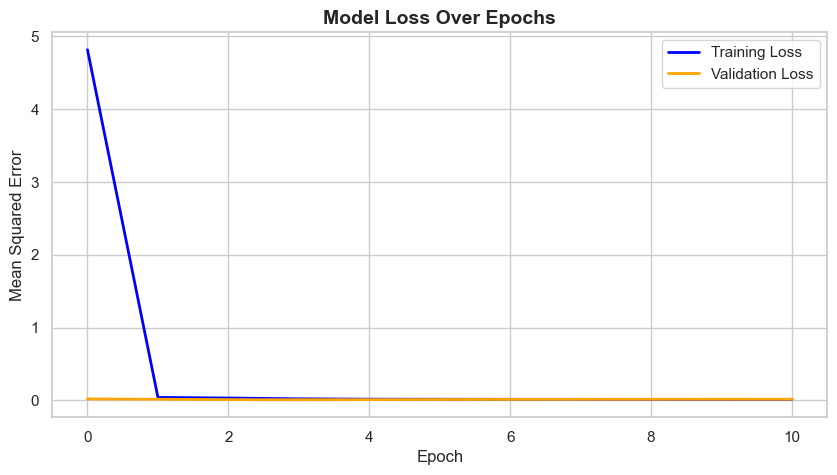

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Apply seaborn whitegrid theme for nicer aesthetics
sns.set_theme(style="whitegrid")

if DATALOAD_SUCCESS:
    plt.figure(figsize=(10, 5))
    if 'history' in locals() and hasattr(history, 'history'):
        plt.plot(history.history['loss'], label='Training Loss', color='blue', linewidth=2)
        if 'val_loss' in history.history:
            plt.plot(history.history['val_loss'], label='Validation Loss', color='orange', linewidth=2)
        plt.title('Model Loss Over Epochs', fontsize=12, fontweight='bold')
        plt.ylabel('Mean Squared Error', fontsize=12)
        plt.xlabel('Epoch', fontsize=12)
        plt.legend(frameon=True, fontsize=12)
        plt.show()
    else:
        print("Training history not found. Make sure model was trained!")
#Note(Ronald): Validation is too small to tell the difference.


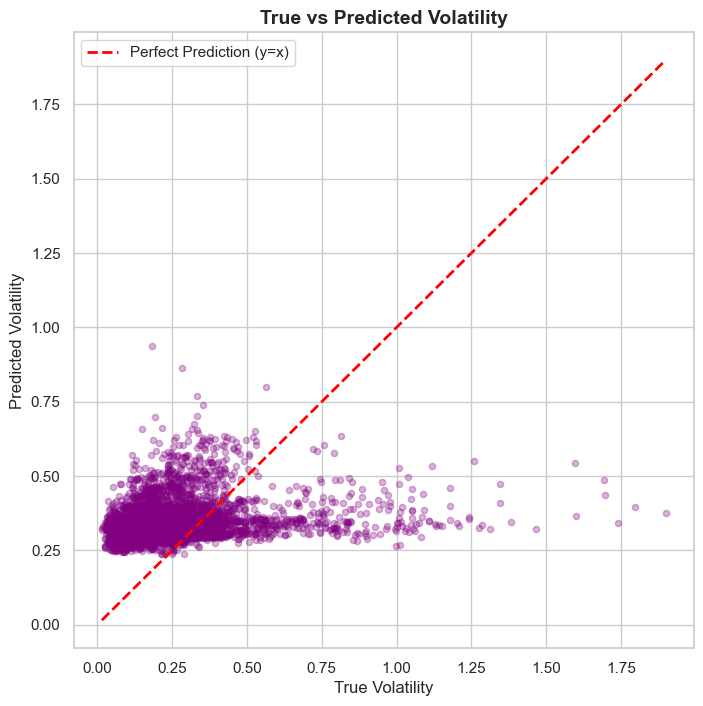

In [8]:
if DATALOAD_SUCCESS:
    plt.figure(figsize=(8, 8))
    plt.scatter(all_targets, all_preds, alpha=0.3, color='purple', s=20)
    
    # Plot perfect prediction reference line (y = x)
    min_val = min(np.min(all_targets), np.min(all_preds))
    max_val = max(np.max(all_targets), np.max(all_preds))
    plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Prediction (y=x)')
    
    plt.title('True vs Predicted Volatility', fontsize=14, fontweight='bold')
    plt.xlabel('True Volatility', fontsize=12)
    plt.ylabel('Predicted Volatility', fontsize=12)
    plt.legend(frameon=True, fontsize=11)
    plt.show()


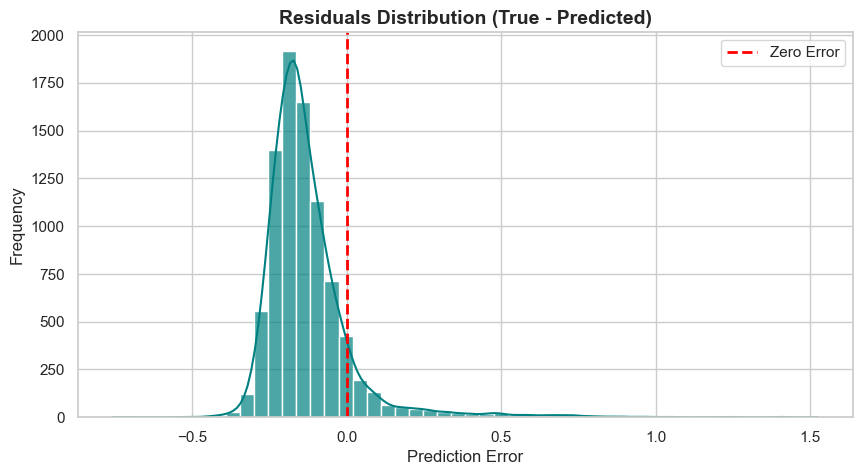

In [9]:
if DATALOAD_SUCCESS:
    residuals = all_targets - all_preds
    
    plt.figure(figsize=(10, 5))
    sns.histplot(residuals, bins=50, kde=True, color='teal', edgecolor='white', alpha=0.7)
    plt.axvline(0, color='red', linestyle='--', linewidth=2, label='Zero Error')
    
    plt.title('Residuals Distribution (True - Predicted)', fontsize=14, fontweight='bold')
    plt.xlabel('Prediction Error', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.legend(frameon=True, fontsize=11)
    plt.show()
